In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("=" * 60)
print("DAY 2: BUILDING DECISION TREE FROM SCRATCH")
print("=" * 60)

# ============================================
# PART 1: GINI IMPURITY FUNCTION
# ============================================

def gini_impurity(y):
    """
    Calculate Gini impurity for a set of labels

    Formula: Gini = 1 - Σ(p_i)²

    Parameters:
    y: array of labels

    Returns:
    gini: float between 0 and 1
    """
    if len(y) == 0:
        return 0

    # Get unique classes and their counts
    classes, counts = np.unique(y, return_counts=True)

    # Calculate probabilities
    probabilities = counts / len(y)

    # Calculate Gini: 1 - sum(p²)
    gini = 1 - np.sum(probabilities ** 2)

    return gini

# Test Gini function
print("\n📊 Testing Gini Impurity:")
print(f"  All same class [0,0,0,0]: Gini = {gini_impurity([0,0,0,0]):.4f} (should be 0)")
print(f"  50/50 split [0,0,1,1]: Gini = {gini_impurity([0,0,1,1]):.4f} (should be 0.5)")
print(f"  3 classes [0,0,1,2]: Gini = {gini_impurity([0,0,1,2]):.4f}")

# ============================================
# PART 2: INFORMATION GAIN FUNCTION
# ============================================

def information_gain(y_parent, y_left, y_right):
    """
    Calculate information gain from a split

    Formula: IG = Gini(parent) - [weight_left × Gini(left) + weight_right × Gini(right)]

    Parameters:
    y_parent: labels before split
    y_left: labels that go left
    y_right: labels that go right

    Returns:
    gain: information gain
    """
    # Calculate parent Gini
    gini_parent = gini_impurity(y_parent)

    # Calculate weighted Gini of children
    n_parent = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)

    gini_left = gini_impurity(y_left)
    gini_right = gini_impurity(y_right)

    weighted_gini = (n_left / n_parent) * gini_left + (n_right / n_parent) * gini_right

    # Information gain
    gain = gini_parent - weighted_gini

    return gain

# Test Information Gain
print("\n📊 Testing Information Gain:")
y_parent = [0,0,0,1,1,1]  # 3 of each
y_left = [0,0,0]           # Pure
y_right = [1,1,1]          # Pure
gain = information_gain(y_parent, y_left, y_right)
print(f"  Perfect split: IG = {gain:.4f} (should be 0.5)")
# ============================================
# PART 3: FIND BEST SPLIT FOR A FEATURE
# ============================================

def find_best_split_for_feature(X_feature, y):
    """
    Find the best threshold to split a single feature

    Parameters:
    X_feature: values of one feature (1D array)
    y: labels

    Returns:
    best_threshold: best value to split on
    best_gain: highest information gain
    """
    # Get unique sorted values
    unique_values = np.unique(X_feature)

    if len(unique_values) == 1:
        return None, 0

    best_gain = 0
    best_threshold = None

    # Try each possible threshold (midpoint between values)
    for i in range(len(unique_values) - 1):
        threshold = (unique_values[i] + unique_values[i+1]) / 2

        # Split the data
        left_mask = X_feature <= threshold
        right_mask = X_feature > threshold

        y_left = y[left_mask]
        y_right = y[right_mask]

        # Skip if either side is empty
        if len(y_left) == 0 or len(y_right) == 0:
            continue

        # Calculate information gain
        gain = information_gain(y, y_left, y_right)

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold

    return best_threshold, best_gain


def find_best_split(X, y):
    """
    Find the best feature and threshold to split on

    Parameters:
    X: features (2D array)
    y: labels

    Returns:
    best_feature_idx: index of best feature
    best_threshold: best threshold value
    best_gain: highest information gain
    """
    n_features = X.shape[1]
    best_feature_idx = None
    best_threshold = None
    best_gain = 0

    for feature_idx in range(n_features):
        X_feature = X[:, feature_idx]
        threshold, gain = find_best_split_for_feature(X_feature, y)

        if gain > best_gain:
            best_gain = gain
            best_feature_idx = feature_idx
            best_threshold = threshold

    return best_feature_idx, best_threshold, best_gain

# ============================================
# PART 4: DECISION TREE FROM SCRATCH
# ============================================

class DecisionTreeFromScratch:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        """Build the decision tree"""
        self.n_classes = len(np.unique(y))
        self.tree = self._build_tree(X, y, depth=0)
        return self

    def _build_tree(self, X, y, depth):
        """
        Recursively build the tree
        """
        n_samples = len(y)
        n_classes = len(np.unique(y))

        # Stopping conditions
        # 1. All samples same class
        if n_classes == 1:
            return {'type': 'leaf', 'class': y[0], 'n_samples': n_samples}

        # 2. Max depth reached
        if self.max_depth is not None and depth >= self.max_depth:
            majority_class = np.bincount(y).argmax()
            return {'type': 'leaf', 'class': majority_class, 'n_samples': n_samples}

        # 3. Not enough samples to split
        if n_samples < self.min_samples_split:
            majority_class = np.bincount(y).argmax()
            return {'type': 'leaf', 'class': majority_class, 'n_samples': n_samples}

        # Find best split
        feature_idx, threshold, gain = find_best_split(X, y)

        # If no good split found
        if feature_idx is None or gain == 0:
            majority_class = np.bincount(y).argmax()
            return {'type': 'leaf', 'class': majority_class, 'n_samples': n_samples}

        # Split the data
        left_mask = X[:, feature_idx] <= threshold
        right_mask = X[:, feature_idx] > threshold

        X_left = X[left_mask]
        y_left = y[left_mask]
        X_right = X[right_mask]
        y_right = y[right_mask]

        # Recursively build children
        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        # Return node
        return {
            'type': 'node',
            'feature_idx': feature_idx,
            'threshold': threshold,
            'left': left_child,
            'right': right_child,
            'gain': gain,
            'n_samples': n_samples
        }

    def predict_single(self, x, node):
        """Predict a single sample"""
        if node['type'] == 'leaf':
            return node['class']

        if x[node['feature_idx']] <= node['threshold']:
            return self.predict_single(x, node['left'])
        else:
            return self.predict_single(x, node['right'])

    def predict(self, X):
        """Predict multiple samples"""
        return np.array([self.predict_single(x, self.tree) for x in X])

    def print_tree(self, node=None, depth=0):
        """Print the tree structure"""
        if node is None:
            node = self.tree

        indent = "  " * depth

        if node['type'] == 'leaf':
            print(f"{indent}└─ Predict: Class {node['class']} ({node['n_samples']} samples)")
        else:
            print(f"{indent}├─ Feature {node['feature_idx']} ≤ {node['threshold']:.2f}? (gain={node['gain']:.4f}, {node['n_samples']} samples)")
            print(f"{indent}│  ├─ YES:")
            self.print_tree(node['left'], depth + 2)
            print(f"{indent}│  └─ NO:")
            self.print_tree(node['right'], depth + 2)
    def get_feature_importance(self, feature_names=None):
        """
        Calculate feature importance from the tree

        Returns:
        importance: array of importance scores for each feature
        """
        importance = np.zeros(self.n_features)
        self._accumulate_importance(self.tree, importance)

        # Normalize to sum to 1
        importance = importance / np.sum(importance)

        if feature_names is not None:
            for name, imp in zip(feature_names, importance):
                print(f"  {name:20s}: {imp:.4f}")

        return importance

    def _accumulate_importance(self, node, importance):
        """Recursively accumulate Gini reductions"""
        if node['type'] == 'leaf':
            return

        # Add Gini reduction at this node
        feature_idx = node['feature']
        gain = node['gain']
        n_samples = node['n_samples']

        importance[feature_idx] += gain * n_samples

        # Recurse to children
        self._accumulate_importance(node['left'], importance)
        self._accumulate_importance(node['right'], importance)

DAY 2: BUILDING DECISION TREE FROM SCRATCH

📊 Testing Gini Impurity:
  All same class [0,0,0,0]: Gini = 0.0000 (should be 0)
  50/50 split [0,0,1,1]: Gini = 0.5000 (should be 0.5)
  3 classes [0,0,1,2]: Gini = 0.6250

📊 Testing Information Gain:
  Perfect split: IG = 0.5000 (should be 0.5)


In [10]:
# ============================================
# PART 5: TEST OUR DECISION TREE
# ============================================

# Load data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train our tree
print("\n" + "=" * 60)
print("TRAINING OUR DECISION TREE FROM SCRATCH")
print("=" * 60)

my_tree = DecisionTreeFromScratch(max_depth=3, min_samples_split=5)
my_tree.fit(X_train, y_train)

# Print the tree structure
print("\n🌳 MY TREE STRUCTURE:")
my_tree.print_tree()

# Predict
y_pred = my_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ My Tree Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

# Compare with sklearn
from sklearn.tree import DecisionTreeClassifier
sk_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
sk_tree.fit(X_train, y_train)
sk_pred = sk_tree.predict(X_test)
sk_accuracy = accuracy_score(y_test, sk_pred)

print(f"\n📊 Comparison:")
print(f"  My Decision Tree: {accuracy:.4f}")
print(f"  Sklearn Decision Tree: {sk_accuracy:.4f}")

if abs(accuracy - sk_accuracy) < 0.05:
    print("  ✅ My tree matches sklearn!")


TRAINING OUR DECISION TREE FROM SCRATCH

🌳 MY TREE STRUCTURE:
├─ Feature 2 ≤ 2.45? (gain=0.3333, 120 samples)
│  ├─ YES:
    └─ Predict: Class 0 (40 samples)
│  └─ NO:
    ├─ Feature 3 ≤ 1.65? (gain=0.4060, 80 samples)
    │  ├─ YES:
        ├─ Feature 2 ≤ 4.95? (gain=0.0969, 42 samples)
        │  ├─ YES:
            └─ Predict: Class 1 (38 samples)
        │  └─ NO:
            └─ Predict: Class 2 (4 samples)
    │  └─ NO:
        ├─ Feature 2 ≤ 4.85? (gain=0.0162, 38 samples)
        │  ├─ YES:
            └─ Predict: Class 2 (3 samples)
        │  └─ NO:
            └─ Predict: Class 2 (35 samples)

✅ My Tree Accuracy: 0.9667 (96.7%)

📊 Comparison:
  My Decision Tree: 0.9667
  Sklearn Decision Tree: 0.9667
  ✅ My tree matches sklearn!


├─ Feature 1 ≤ 2.45? (gain=0.3333, 120 samples)
│  ├─ YES:
    └─ Predict: Class 0 (40 samples)
│  └─ NO:
    ├─ Feature 1 ≤ 4.95? (gain=0.3850, 80 samples)
    │  ├─ YES:
        ├─ Feature 1 ≤ 4.75? (gain=0.0438, 43 samples)
        │  ├─ YES:
            └─ Predict: Class 1 (36 samples)
        │  └─ NO:
            └─ Predict: Class 1 (7 samples)
    │  └─ NO:
        ├─ Feature 0 ≤ 6.10? (gain=0.0063, 37 samples)
        │  ├─ YES:
            └─ Predict: Class 2 (7 samples)
        │  └─ NO:
            └─ Predict: Class 2 (30 samples)


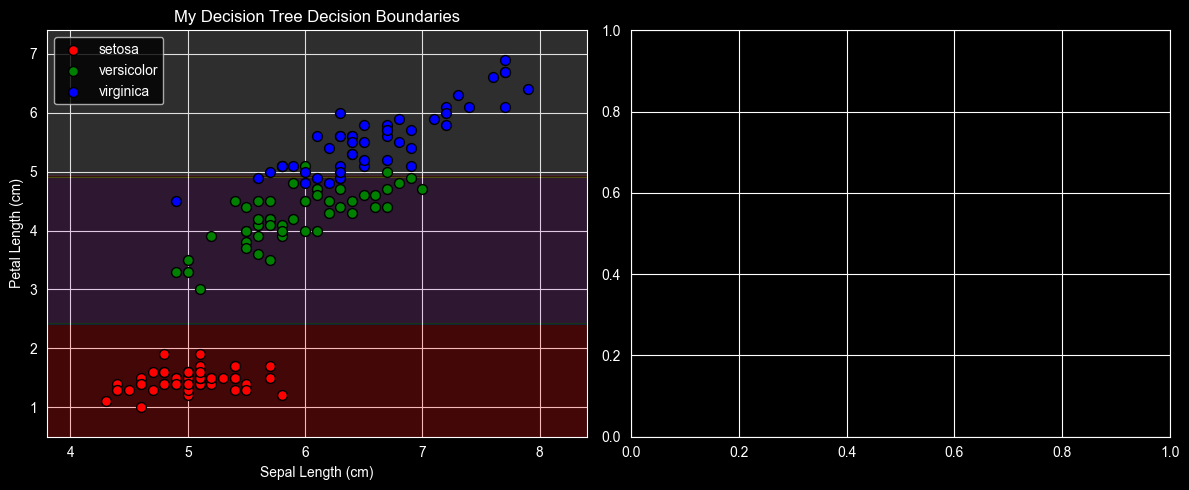

In [11]:
# ============================================
# PART 6: VISUALIZE DECISION BOUNDARIES
# ============================================

# Use only 2 features for visualization
X_2d = X[:, [0, 2]]  # sepal length and petal length
feature_names_2d = ['sepal length', 'petal length']

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

# Train on 2 features
my_tree_2d = DecisionTreeFromScratch(max_depth=3)
my_tree_2d.fit(X_train_2d, y_train_2d)

# Create mesh grid
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict on mesh
Z = my_tree_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    mask = y == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=iris.target_names[i], edgecolor='black', s=50)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('My Decision Tree Decision Boundaries')
plt.legend()

plt.subplot(1, 2, 2)
my_tree_2d.print_tree()

plt.tight_layout()
plt.show()

DAY 4: FEATURE IMPORTANCE WITH RANDOM FOREST

📊 Breast Cancer Dataset:
  Samples: 569
  Features: 30

TOP 10 MOST IMPORTANT FEATURES
   1. worst area               : 0.1383
   2. worst concave points     : 0.1330
   3. worst radius             : 0.1008
   4. mean concave points      : 0.0985
   5. worst perimeter          : 0.0722
   6. mean perimeter           : 0.0686
   7. mean radius              : 0.0675
   8. mean concavity           : 0.0574
   9. mean area                : 0.0506
  10. worst concavity          : 0.0315


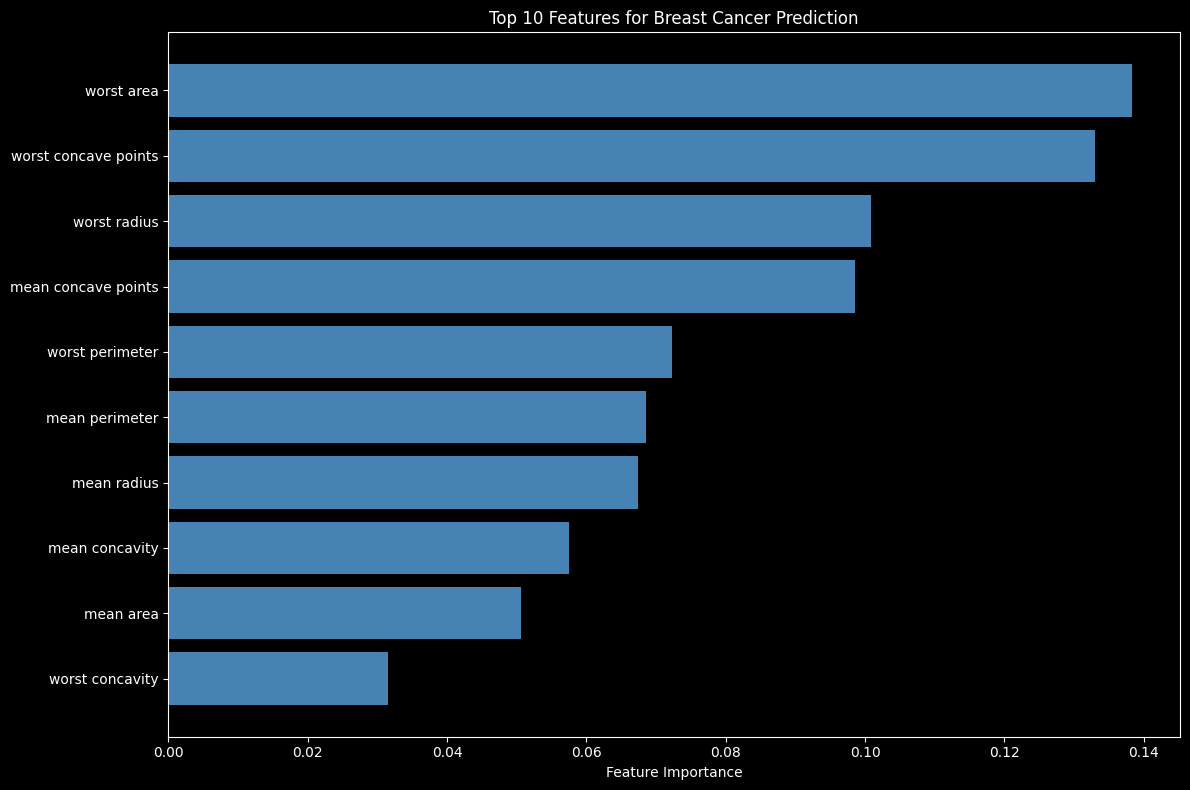


MODEL COMPARISON
All 30 features: 0.9561
Top 5 features only: 0.9298

💡 INSIGHT:
  Using only the 5 most important features achieved similar accuracy!
  This means we can simplify the model without losing performance.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("=" * 60)
print("DAY 4: FEATURE IMPORTANCE WITH RANDOM FOREST")
print("=" * 60)

# Load a dataset where feature importance makes sense
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"\n📊 Breast Cancer Dataset:")
print(f"  Samples: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
importance = rf.feature_importances_

# Sort features by importance
sorted_idx = np.argsort(importance)[::-1]

print("\n" + "=" * 60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 60)

for i in range(10):
    idx = sorted_idx[i]
    print(f"  {i+1:2d}. {feature_names[idx]:25s}: {importance[idx]:.4f}")

# Plot
plt.figure(figsize=(12, 8))
plt.barh(range(10), importance[sorted_idx[:10]][::-1], color='steelblue')
plt.yticks(range(10), [feature_names[i] for i in sorted_idx[:10]][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 10 Features for Breast Cancer Prediction')
plt.tight_layout()
plt.show()

# Train with only top 5 features
top5_idx = sorted_idx[:5]
X_train_top5 = X_train[:, top5_idx]
X_test_top5 = X_test[:, top5_idx]

rf_top5 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_top5.fit(X_train_top5, y_train)
y_pred_top5 = rf_top5.predict(X_test_top5)
accuracy_top5 = accuracy_score(y_test, y_pred_top5)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"All 30 features: {accuracy_score(y_test, rf.predict(X_test)):.4f}")
print(f"Top 5 features only: {accuracy_top5:.4f}")

print("\n💡 INSIGHT:")
print("  Using only the 5 most important features achieved similar accuracy!")
print("  This means we can simplify the model without losing performance.")